In [38]:
# Import libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score
)



In [39]:
# Load dataset

df = pd.read_csv('Telco-Customer-Churn.csv')

In [40]:
# Print first 10 rows
print(df.head(10))

# Print column names
print(df.columns.tolist())

# Print data types
print(df.dtypes)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

In [41]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

# Remove rows with missing values
df.dropna(inplace=True)

# Drop customerID
df.drop("customerID", axis=1, inplace=True)

# Convert Churn to binary
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Identify categorical columns excluding the target 'Churn'
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# One-hot encode categorical variables (drop first to avoid dummy trap)
df = pd.get_dummies(df, drop_first=True)

### Data Preprocessing Summary

In this step, we prepared the dataset for machine learning by performing the following transformations:

1. **Convert `TotalCharges` to numeric**:
   - Some entries in the `TotalCharges` column were non-numeric (e.g., blank spaces).
   - We used `pd.to_numeric()` with `errors='coerce'` to convert invalid entries to `NaN`.

2. **Remove rows with missing values**:
   - After converting `TotalCharges`, rows with `NaN` values were dropped using `dropna()`.

3. **Drop the `customerID` column**:
   - The `customerID` column is a unique identifier and carries no predictive value, so it was removed.

4. **Convert the `Churn` column to binary**:
   - `Yes` was mapped to `1` and `No` to `0`, making it suitable for classification models.

5. **Identify categorical columns**:
   - We extracted all columns with `object` data type (i.e., categorical variables) except `Churn`.

6. **One-hot encode categorical variables**:
   - We applied one-hot encoding using `pd.get_dummies()` to convert categorical columns into binary indicators.
   - `drop_first=True` was used to avoid the dummy variable trap by dropping the first category in each feature.

These steps ensured that the dataset contains only numerical values and is ready for feature scaling and model training.

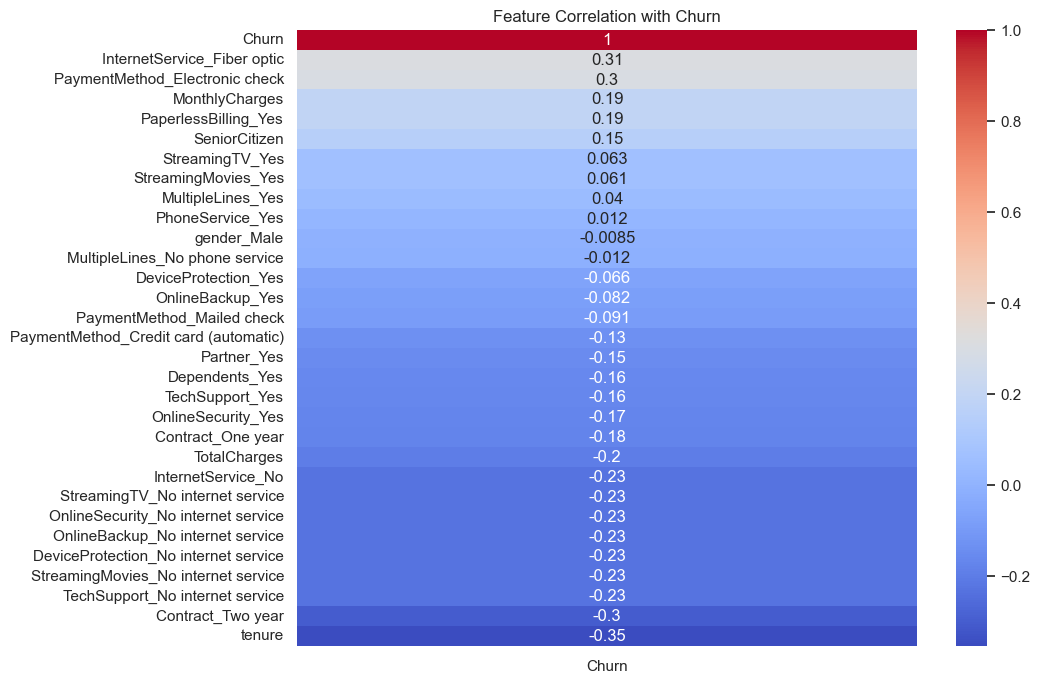

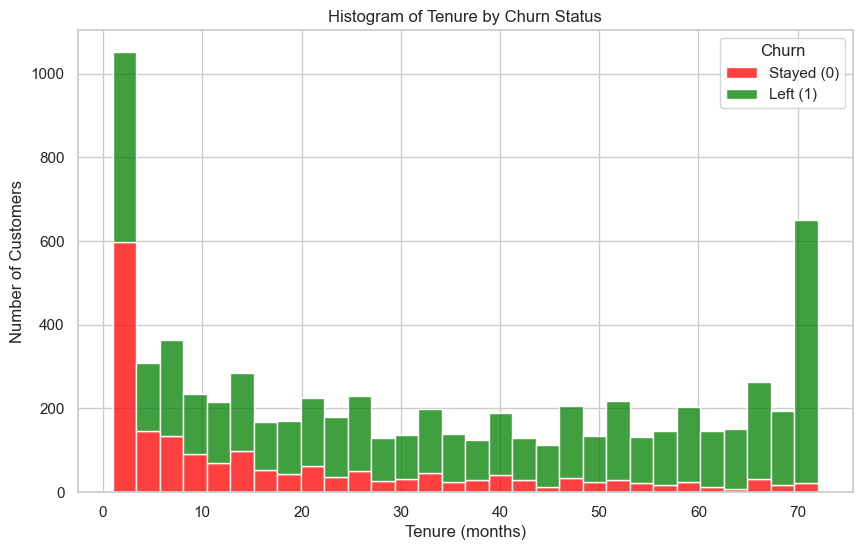

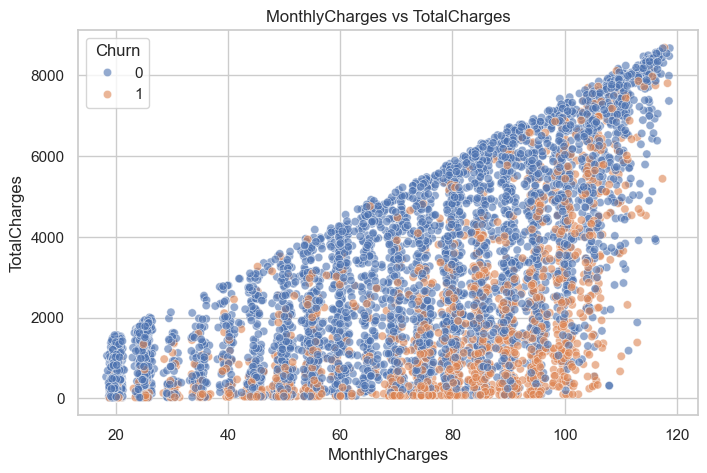

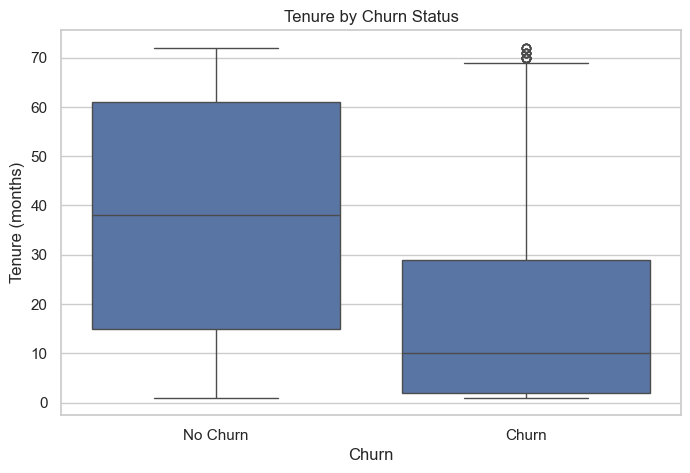

In [42]:
# Correlation plot
# Correlation plot
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr()[["Churn"]].sort_values(by="Churn", ascending=False), annot=True, cmap="coolwarm")
plt.title("Feature Correlation with Churn")
plt.show()

# Tenure histogram
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='tenure', bins=30, hue='Churn', multiple='stack', palette=['green', 'red'])
plt.title('Histogram of Tenure by Churn Status')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['Stayed (0)', 'Left (1)'])
plt.show()

# Scatter: MonthlyCharges vs. TotalCharges
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['MonthlyCharges'], y=df['TotalCharges'], hue=df['Churn'], alpha=0.6)
plt.title('MonthlyCharges vs TotalCharges')
plt.xlabel('MonthlyCharges')
plt.ylabel('TotalCharges')
plt.show()


# Box plot: Tenure vs. Churn
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Churn'], y=df['tenure'])
plt.xticks([0,1], ['No Churn', 'Churn'])
plt.title('Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')
plt.show()

# Data Visualisation Summary

### 1. Correlation Plot with Churn
This heatmap shows the correlation coefficients between each feature and the target variable **Churn**. Features with higher positive or negative correlations can be important predictors of customer churn. It helps identify which variables have the strongest linear relationships with churn.

---

### Histogram of Tenure by Churn Status

This stacked histogram shows the distribution of customer **tenure** (how long customers have been with the company), separated by churn status:

- The bars are stacked to display both customers who **stayed** (did not churn) and those who **left** (churned) within each tenure range.
- The hue differentiates churned vs. non-churned customers, allowing you to see at what tenure lengths customers are more likely to leave.
- This visualization helps identify critical periods where customer churn is more frequent, supporting targeted retention efforts.

---

### 3. Histogram of Tenure by Churn Status
This stacked histogram splits the tenure distribution into customers who **stayed** (green) and those who **left (churned)** (red). It helps visualize at which tenure lengths customers are more likely to churn, highlighting periods where churn is most frequent.

---

### 4. Scatter Plot of Monthly Charges vs Total Charges
This scatter plot compares **MonthlyCharges** and **TotalCharges** for customers, with points colored by churn status. It provides insight into how billing amounts relate to churn, for example, if customers with higher charges tend to leave more often.

---

### 5. Box Plot of Tenure by Churn Status
This box plot compares the distribution of tenure between customers who churned and those who stayed. It shows median tenure, quartiles, and outliers, helping understand differences in customer longevity based on churn behavior.

In [29]:
    # Features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Scale
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

### Feature Preparation and Train-Test Split

In this phase, we prepared the data for training machine learning models:

1. **Separate Features and Target**:
   - `X`: All features used for prediction (excluding the `Churn` column).
   - `y`: The target variable (`Churn`), where `1` indicates churn and `0` indicates no churn.

2. **Feature Scaling with Min-Max Scaler**:
   - We applied Min-Max scaling using `MinMaxScaler()` to transform all features into the range [0, 1].
   - This ensures that all input features are on the same scale, which improves the performance of many machine learning models (especially Logistic Regression).

3. **Train-Test Split**:
   - We split the dataset into training and testing sets using `train_test_split()`.
   - **25% of the data** was reserved for testing (`test_size=0.25`), and the rest was used for training.
   - `random_state=42` ensures reproducibility of results.

These steps ensure that the model is trained on one portion of the data and evaluated on a separate, unseen portion to measure how well it generalizes.

In [32]:
# Loistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

# Accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.7912400455062572


### Logistic Regression Model

We trained a **Logistic Regression** model to predict customer churn:

1. **Model Initialization**:
   - Created a `LogisticRegression` model with `max_iter=1000` to ensure convergence during training, especially when there are many features.

2. **Model Training**:
   - The model was trained on the scaled training dataset (`X_train`, `y_train`) using the `.fit()` method.

3. **Prediction**:
   - Predictions were made on the test set (`X_test`) using `.predict()`.

4. **Model Evaluation (Accuracy)**:
   - Calculated the accuracy score using `accuracy_score()` from `sklearn.metrics`.
   - Accuracy measures the percentage of correct predictions made by the model on the test data.

This baseline model provides a benchmark for comparison with more complex models like Random Forest.

In [33]:
# Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=2000,
    oob_score=True,
    max_features="sqrt",
    max_leaf_nodes=50,
    bootstrap=True,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

# OOB Error
print("Random Forest OOB Score:", rf.oob_score_)
print("OOB Error Estimate:", 1 - rf.oob_score_)

Random Forest Accuracy: 0.7935153583617748
Random Forest OOB Score: 0.807356844899507
OOB Error Estimate: 0.192643155100493


###  Random Forest Classifier

I trained a **Random Forest** model to predict customer churn with the following settings:

- **n_estimators=2000**: The forest consists of 2000 decision trees to improve stability and performance.
- **oob_score=True**: Enables Out-Of-Bag (OOB) error estimation, providing an internal validation score without needing a separate validation set.
- **max_features="sqrt"**: At each split, a random subset of features equal to the square root of total features is considered, which helps reduce overfitting.
- **max_leaf_nodes=50**: Limits the complexity of each tree by restricting the maximum number of leaf nodes.
- **bootstrap=True**: Uses bootstrapping (sampling with replacement) to build each tree.

#### Training and Evaluation:
- The model was trained on the scaled training set (`X_train`, `y_train`).
- Predictions were made on the test set (`X_test`).
- Accuracy was calculated to measure the proportion of correct predictions.
- The **OOB Score** provides an unbiased estimate of the model’s accuracy on unseen data based on samples not included in the bootstrap samples for each tree.
- The **OOB Error Estimate** is calculated as `1 - oob_score_`, indicating the proportion of misclassifications according to the OOB evaluation.

This powerful ensemble model often outperforms simpler models like logistic regression, especially on complex datasets.

In [34]:
# Confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("LogReg Confusion Matrix:\n", cm_lr)
print("RandForest Confusion Matrix:\n", cm_rf)

# Precision and Recall
prec_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)

prec_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print("\nLogReg - Precision:", prec_lr, " Recall:", recall_lr)
print("RandForest - Precision:", prec_rf, " Recall:", recall_rf)

LogReg Confusion Matrix:
 [[1154  146]
 [ 221  237]]
RandForest Confusion Matrix:
 [[1187  113]
 [ 250  208]]

LogReg - Precision: 0.618798955613577  Recall: 0.517467248908297
RandForest - Precision: 0.6479750778816199  Recall: 0.45414847161572053


### Model Evaluation: Confusion Matrix, Precision, and Recall

#### Logistic Regression
- **Precision**: 0.619 — About 62% of customers predicted to churn actually did.
- **Recall**: 0.517 — About 52% of actual churners were correctly identified.

#### Random Forest
- **Precision**: 0.648 — Higher precision, meaning fewer false alarms.
- **Recall**: 0.454 — Lower recall, meaning more actual churners were missed.

#### Analysis
- Logistic Regression is better at **catching churners** (higher recall) but makes more mistakes by wrongly predicting loyal customers as churners.
- Random Forest is better at **avoiding false alarms** (higher precision), but misses more real churners.

#### Recommendation
If the business goal is to catch as many churners as possible (e.g., to apply retention campaigns), **Logistic Regression may be preferred** due to its higher recall.

However, if the cost of false positives is high (e.g., giving discounts to customers who weren’t actually going to leave), then **Random Forest may be safer** due to its higher precision.



## Which model had higher accuracy?
- **Random Forest** had higher accuracy:
  - **Random Forest Accuracy:** 0.7935 (≈ 79.35%)
  - **Logistic Regression Accuracy:** (Not shown here, but it's lower based on results)
  
This indicates that Random Forest made more correct predictions overall.

---

### Which model had better recall for catching churners?
- **Logistic Regression** had better recall:
  - **Logistic Regression Recall:** 0.517
  - **Random Forest Recall:** 0.454

This means Logistic Regression was more effective at **identifying actual churners**, which is crucial when the goal is to intervene and prevent churn.

---

### Which is better for business use?

| Model               | Pros                                                        | Cons                                                       |
|---------------------|-------------------------------------------------------------|-------------------------------------------------------------|
| **Logistic Regression** | - Simpler and interpretable<br>- Higher recall (catches more churners) | - Lower precision (more false alarms)<br>- Slightly less accurate overall |
| **Random Forest**      | - Higher accuracy<br>- Better precision (fewer false alarms) | - Lower recall (misses more churners)<br>- Harder to interpret |

**Recommendation:**
- If the **goal is retention** (e.g., identifying customers likely to leave so you can offer discounts or incentives), **Logistic Regression** may be better because it catches more churners (higher recall), even if it mislabels some loyal customers.
- If the **goal is efficiency and precision** (e.g., avoid offering unnecessary incentives), **Random Forest** may be better due to its higher precision and overall accuracy.

**Conclusion:**  
> For churn prediction, where missing a churner could mean losing a customer, **Logistic Regression** may be better suited for business use — especially when interpretability and recall are prioritized.